# Notebook to show classification feature extraction

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input


2026-02-05 10:35:26.260064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770284126.500123   15216 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770284126.570585   15216 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770284127.211136   15216 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770284127.211181   15216 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770284127.211185   15216 computation_placer.cc:177] computation placer alr

In [52]:

def make_gradcam_heatmap(
    image_array: np.ndarray,
    model: tf.keras.Model,
    last_conv_layer_name: str = "top_activation",
) -> tuple[np.ndarray, int]:
    """
    Generate a Grad-CAM heatmap for a given image and model.

    Parameters
    ----------
    image_array : np.ndarray
        Preprocessed image array with shape (1, H, W, C).
    model : tf.keras.Model
        Classification model that uses an EfficientNet backbone.
    last_conv_layer_name : str, optional
        Name of the last convolutional layer inside the EfficientNet backbone.
        Default is 'top_activation'.

    Returns
    -------
    heatmap : np.ndarray
        Grad-CAM heatmap normalized between 0 and 1.
    pred_index : int
        Index of the predicted class.
    """
    # Get the EfficientNet backbone (nested model at index 1)
    efficientnet_model = model.layers[1]

    # Create a model that outputs the conv layer from EfficientNet
    conv_model = tf.keras.models.Model(
        inputs=efficientnet_model.input,
        outputs=efficientnet_model.get_layer(last_conv_layer_name).output
    )

    # Create a model that takes conv output and produces final predictions
    # We need to get all layers after EfficientNet
    classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
    x = classifier_input

    # Apply global average pooling (layer 2 in your model)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Apply the remaining layers (dense, dropout, dense_1, dense_2)
    for layer in model.layers[3:]:  # Skip input, efficientnet, and gap
        x = layer(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    # Compute gradients
    with tf.GradientTape() as tape:
        # Get conv outputs
        conv_outputs = conv_model(image_array)
        tape.watch(conv_outputs)

        # Get predictions
        predictions = classifier_model(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
        probability = np.max(predictions[0])
        probability = round(float(probability), 3)
    # Gradient of the predicted class with respect to the conv layer output
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling on gradients (importance weights)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv outputs by the gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)

    return heatmap.numpy(), int(pred_index.numpy()), probability


In [53]:

def overlay_gradcam(
    image_path: str,
    heatmap: np.ndarray,
    alpha: float = 0.6,
    colormap: int = cv2.COLORMAP_JET,
    mask_background: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    """
    Overlay Grad-CAM heatmap on the original image with optional background masking.

    Parameters
    ----------
    image_path : str
        Path to the original image.
    heatmap : np.ndarray
        Grad-CAM heatmap.
    alpha : float, optional
        Transparency factor for the heatmap overlay.
    colormap : int, optional
        OpenCV colormap constant. Default is cv2.COLORMAP_JET.
    mask_background : bool, optional
        If True, applies heatmap only to the foreground object.

    Returns
    -------
    img : np.ndarray
        Original image as array.
    superimposed_img : np.ndarray
        Image with heatmap overlay.
    """
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Ensure RGB
    img = cv2.resize(img, (224, 224))

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply colormap (OpenCV applies it in BGR)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    # Convert heatmap from BGR to RGB so it matches the image
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    if mask_background:
        # Simple background mask (assuming white background)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 245, 255, cv2.THRESH_BINARY_INV)

        # Clean up the mask with morphological operations
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB) / 255.0

        # Superimpose only on masked region
        superimposed_img = img.astype(float) * (1 - mask_3ch * alpha) + heatmap_color.astype(float) * (mask_3ch * alpha)
        superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255))
    else:
        # Original behavior: overlay on entire image
        superimposed_img = heatmap_color * alpha + img
        superimposed_img = np.uint8(superimposed_img)

    return img, superimposed_img


In [61]:

# Usage Example
from tensorflow.keras.models import load_model

categories = ['Boots', 'Flat shoe', 'Heels', 'Sandals', 'Slippers', 'Sneakers']
model = load_model("../models/subcategory_classifier_best.keras")
image_path = "../raw_data/test_images/temp6.jpg"

# Preprocess
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Generate Grad-CAM
heatmap, pred_idx, prob = make_gradcam_heatmap(img_array, model, 'top_activation')


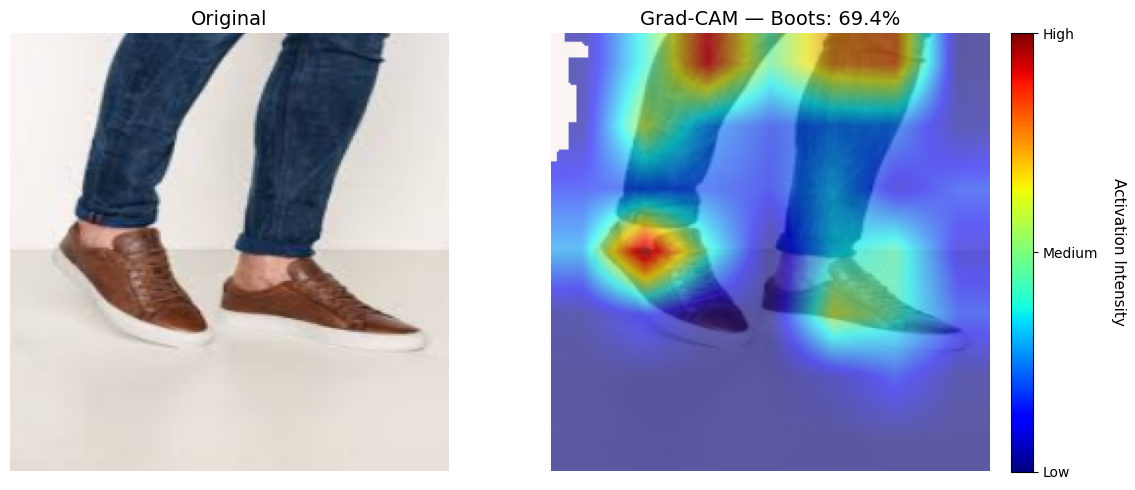

In [63]:
# Overlay
original, overlay = overlay_gradcam(image_path, heatmap, alpha=0.6, mask_background=True)
# Plot with colorbar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
axes[0].imshow(original)
axes[0].set_title("Original", fontsize=14)
axes[0].axis("off")

# Grad-CAM with colorbar
im = axes[1].imshow(overlay)
axes[1].set_title(f"Grad-CAM — {categories[pred_idx]}: {round(prob*100,2)}%", fontsize=14)
axes[1].axis("off")

# Add colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1)),
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)
cbar.set_label('Activation Intensity', rotation=270, labelpad=20, fontsize=11)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Medium', 'High'])

plt.tight_layout()
plt.show()

In [56]:
prob

0.974

In [57]:
prob = round(prob, 2)

In [58]:
prob

0.97